<a href="https://colab.research.google.com/github/ironspiritjeff/Heart-Disease-Classifier/blob/main/Heart_Disease_Project_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

In [ ]:
df = pd.read_csv('heart-disease.csv')

In [ ]:
# Split data into X and y:
X = df.drop('target', axis = 1)
y = df['target']

np.random.seed(7)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
# Put models into a dictionary:
models = {'Logistic Regression': LogisticRegression(max_iter=1000),
          'KNN': KNeighborsClassifier(),
          'RandomForest': RandomForestClassifier()}

# Create a function to fit and score models:
def fit_and_score(models, X_train, X_test, y_train, y_test):
    '''Fits and evaluates given machine learning models
    models: a dict of different skLearn models
    X_train: training data (no labels)
    X_test: testing data (no labels)
    y_train: training labels
    y_test: testing labels
    '''
    np.random.seed(7)
    # Make a dictionary to keep model scores:
    model_scores = {}
    # Loop through models:
    for name, model in models.items():
        # Fit the model to the data:
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to the model score:
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [ ]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

In [ ]:
display(model_scores)

{'Logistic Regression': 0.7704918032786885,
 'KNN': 0.5573770491803278,
 'RandomForest': 0.7213114754098361}

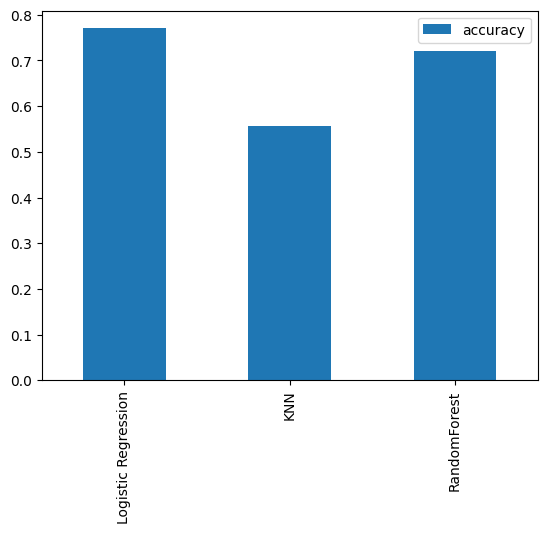

In [ ]:
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar();

### Hyperparameter tuning with `GridSearchCV` for KNN

We'll create a dictionary of hyperparameters for `KNeighborsClassifier` and then use `GridSearchCV` to search for the best `n_neighbors`.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for KNeighborsClassifier
knn_grid = {
    'n_neighbors': range(1, 21, 2) # Try odd numbers from 1 to 19 for n_neighbors
}

# Instantiate GridSearchCV with KNeighborsClassifier
gs_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_grid,
    cv=5, # 5-fold cross-validation
    verbose=True
)

# Fit GridSearchCV to the training data
gs_knn.fit(X_train, y_train)

# Display the best hyperparameters and corresponding score
print(f"Best hyperparameters for KNN: {gs_knn.best_params_}")
print(f"Best score for KNN: {gs_knn.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters for KNN: {'n_neighbors': 15}
Best score for KNN: 0.6735


,Logistic Regression,KNN,RandomForest
accuracy,0.770492,0.673469,0.721311


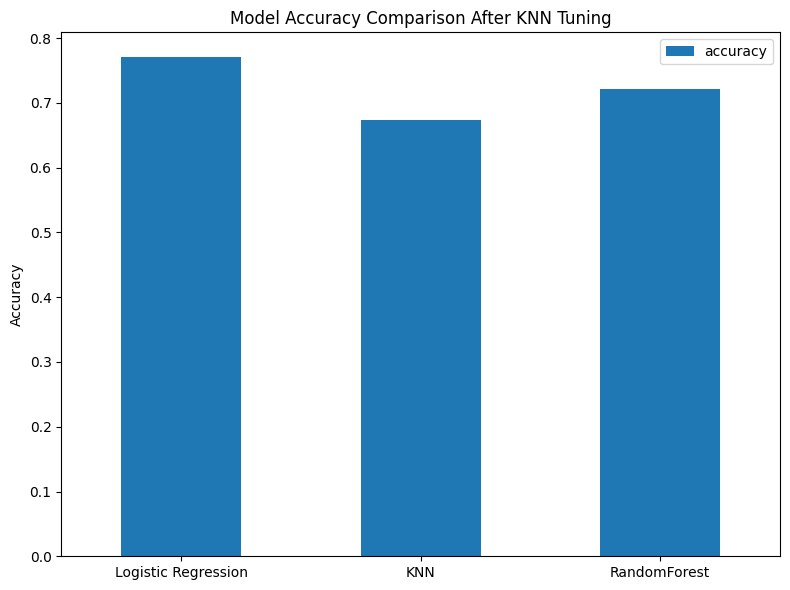

In [ ]:
model_scores['KNN'] = gs_knn.best_score_
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
display(model_compare)

model_compare.T.plot.bar(title='Model Accuracy Comparison After KNN Tuning', figsize=(8, 6));
plt.ylabel('Accuracy');
plt.xticks(rotation=0);
plt.tight_layout();
plt.show();

In [ ]:
 # Tuning KNN:
train_scores = []
test_scores = []

# Create a list of different values for n_neighbors
neighbors = range(1,21)

# Set up KNN instance
knn = KNeighborsClassifier()

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    # fit the algorithm
    knn.fit(X_train,y_train)

    # Update training scores list:
    train_scores.append(knn.score(X_train,y_train))

    # Update the test scores list:
    test_scores.append(knn.score(X_test, y_test))

In [ ]:
train_scores

[1.0,
 0.8099173553719008,
 0.7768595041322314,
 0.756198347107438,
 0.7603305785123967,
 0.731404958677686,
 0.743801652892562,
 0.7148760330578512,
 0.71900826446281,
 0.731404958677686,
 0.7272727272727273,
 0.7231404958677686,
 0.731404958677686,
 0.71900826446281,
 0.7148760330578512,
 0.6900826446280992,
 0.7272727272727273,
 0.71900826446281,
 0.7107438016528925,
 0.7066115702479339]

In [ ]:
test_scores

[0.6065573770491803,
 0.6557377049180327,
 0.6229508196721312,
 0.6229508196721312,
 0.5573770491803278,
 0.639344262295082,
 0.6721311475409836,
 0.6557377049180327,
 0.6065573770491803,
 0.6065573770491803,
 0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6557377049180327,
 0.6557377049180327,
 0.6557377049180327,
 0.6721311475409836,
 0.6721311475409836,
 0.6557377049180327,
 0.6721311475409836]

Maximum KNN Score on the test data: 67.21%


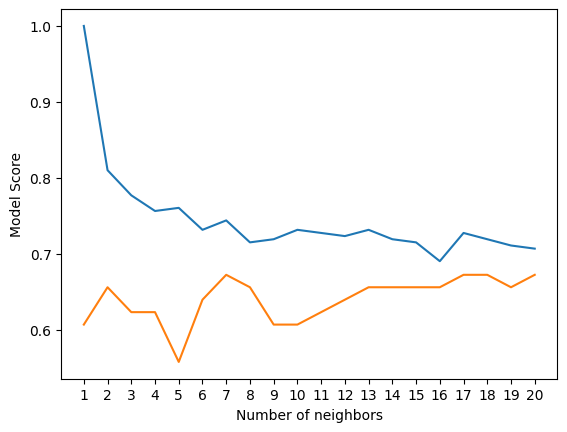

In [ ]:
plt.plot(neighbors, train_scores, label= 'Train Score')
plt.plot(neighbors, test_scores, label='Test Score')
plt.xticks(np.arange(1, 21,1))
plt.xlabel('Number of neighbors')
plt.ylabel('Model Score')
plt.legend
print(f'Maximum KNN Score on the test data: {max(test_scores)*100:.2f}%')

In [ ]:
# model_scores['KNN'] = knn_scaled_score
# model_compare = pd.DataFrame(model_scores, index=['accuracy'])
# display(model_compare)

# model_compare.T.plot.bar(title='Model Accuracy Comparison After KNN Tuning & Scaling', figsize=(8, 6));
# plt.ylabel('Accuracy');
# plt.xticks(rotation=0);
# plt.tight_layout();
# plt.show();

In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (242, 13)
X_test_scaled shape: (61, 13)


In [ ]:
# # Instantiate KNN with the best n_neighbors from tuning
# knn_scaled = KNeighborsClassifier(n_neighbors=15)

# # Fit the model to the scaled training data
# knn_scaled.fit(X_train_scaled, y_train)

# # Evaluate the model on the scaled test data
# knn_scaled_score = knn_scaled.score(X_test_scaled, y_test)

# print(f"KNN score on scaled test data (n_neighbors=15): {knn_scaled_score:.4f}")

### Feature Scaling with `StandardScaler`

We'll use `StandardScaler` to transform our features so they have a mean of 0 and a standard deviation of 1. This helps distance-based algorithms like KNN perform better.

### Stratified Cross-Validation for KNN

We'll use `StratifiedKFold` to ensure each fold has a similar proportion of target classes, providing a more reliable performance estimate for KNN.

In [ ]:
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# # Instantiate KNeighborsClassifier with the best n_neighbors (15)
# knn_stratified = KNeighborsClassifier(n_neighbors=15)

# # Instantiate StratifiedKFold
# # We use the 'shuffle=True' to ensure random shuffling of the data before splitting into folds
# # 'random_state' ensures reproducibility of the splits
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# # Perform stratified cross-validation on the scaled data
# stratified_knn_scores = cross_val_score(
#     estimator=knn_stratified,
#     X=X_train_scaled, # Use the scaled training data
#     y=y_train,
#     cv=skf,
#     scoring='accuracy' # Use accuracy as the scoring metric
# )

# print(f"Stratified Cross-Validation Scores for KNN: {stratified_knn_scores}")
# print(f"Mean Stratified CV Score: {stratified_knn_scores.mean():.4f}")
# print(f"Standard Deviation of Stratified CV Scores: {stratified_knn_scores.std():.4f}")

In [ ]:
# # Instantiate KNN with the best n_neighbors (15)
# knn_pca = KNeighborsClassifier(n_neighbors=15)

# # Fit the model to the PCA-transformed training data
# knn_pca.fit(X_train_pca, y_train)

# # Evaluate the model on the PCA-transformed test data
# knn_pca_score = knn_pca.score(X_test_pca, y_test)

# print(f"KNN score on PCA-transformed test data (n_neighbors=15): {knn_pca_score:.4f}")

# # Update model_scores and model_compare with the new KNN PCA score
# model_scores['KNN_PCA'] = knn_pca_score
# model_compare_pca = pd.DataFrame(model_scores, index=['accuracy'])
# display(model_compare_pca)

# model_compare_pca.T.plot.bar(title='Model Accuracy Comparison (After PCA for KNN)', figsize=(10, 6));
# plt.ylabel('Accuracy');
# plt.xticks(rotation=45, ha='right');
# plt.tight_layout();
# plt.show();

### Dimensionality Reduction with PCA

We'll use Principal Component Analysis (PCA) to reduce the dimensionality of our scaled features. This can help reduce noise and potentially improve model performance, especially for distance-based algorithms like KNN.

In [ ]:
# from sklearn.decomposition import PCA

# # Instantiate PCA (you can specify n_components, or let it determine automatically based on variance ratio)
# pca = PCA(n_components=0.95) # Retain 95% of the variance

# # Fit PCA on the scaled training data and transform both training and test data
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

# print(f"Original number of features: {X_train_scaled.shape[1]}")
# print(f"Number of features after PCA: {X_train_pca.shape[1]}")
# print("X_train_pca shape:", X_train_pca.shape)
# print("X_test_pca shape:", X_test_pca.shape)

In [ ]:
# Put models into a dictionary:
models = {'Logistic Regression': LogisticRegression(max_iter=10000),
          'KNN': KNeighborsClassifier(),
          'RandomForest': RandomForestClassifier()}

# Create a function to fit and score models:
def fit_and_score(models, X_train, X_test, y_train, y_test):
    '''Fits and evaluates given machine learning models
    models: a dict of different skLearn models
    X_train: training data (no labels)
    X_test: testing data (no labels)
    y_train: training labels
    y_test: testing labels
    '''
    np.random.seed(7)
    # Make a dictionary to keep model scores:
    model_scores = {}
    # Loop through models:
    for name, model in models.items():
        # Fit the model to the data:
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to the model score:
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [ ]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

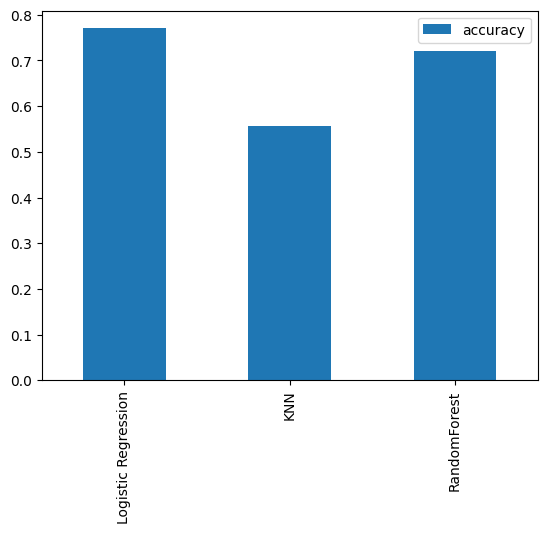

In [ ]:
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar();

# Logistic Regression

In [ ]:
log_reg_grid = {'C': np.logspace(-4, 4, 30),
                'solver': ['liblinear']}
# Set up grid hyperparameter for grid
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose =True)
# Fit grid hyperparameter search model
gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
gs_log_reg.best_params_

{'C': np.float64(0.38566204211634725), 'solver': 'liblinear'}

In [ ]:
gs_log_reg.score(X_test, y_test)

0.7540983606557377

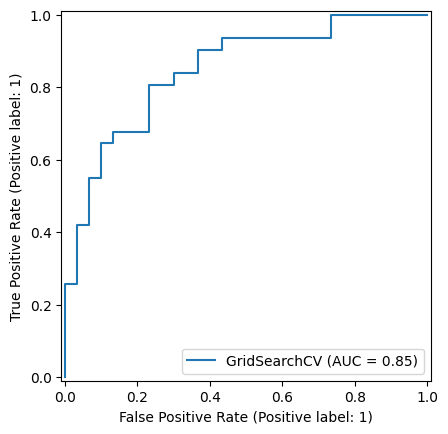

In [ ]:
y_preds = gs_log_reg.predict(X_test)
# Plot ROC Curve and calculate AUC metric
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)

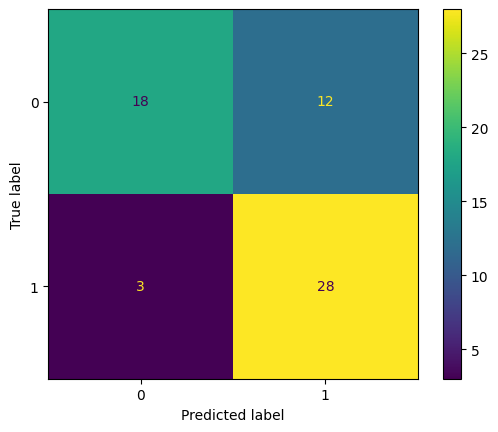

In [ ]:
# To get a confusion matrix, we need predictions and true labels
y_preds = gs_log_reg.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(gs_log_reg, X_test, y_test);


Original predictions (threshold 0.5): [1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1
 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1]
Predictions with new threshold 0.7: [1 1 1 1 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1]

Confusion Matrix with threshold 0.7:


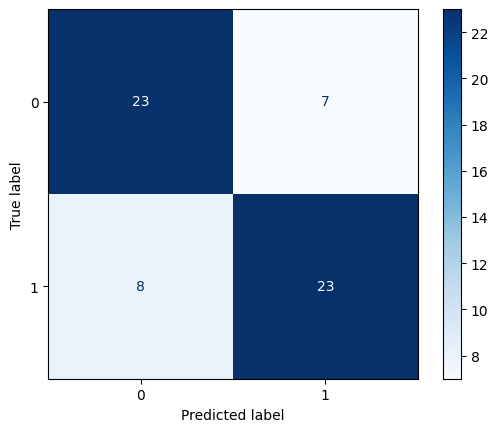

In [ ]:
# Get prediction probabilities from the best Logistic Regression model
y_probs = gs_log_reg.predict_proba(X_test)

# The probabilities are for class 0 and class 1. We are interested in class 1.
y_probs_positive = y_probs[:, 1]

# Define a new classification threshold (e.g., 0.7 to reduce false positives)
new_threshold = 0.7

# Make new predictions based on the custom threshold
y_preds_threshold = (y_probs_positive >= new_threshold).astype(int)

print(f"Original predictions (threshold 0.5): {gs_log_reg.predict(X_test)}")
print(f"Predictions with new threshold {new_threshold}: {y_preds_threshold}")

# Display the confusion matrix for the new predictions
from sklearn.metrics import ConfusionMatrixDisplay

print(f"\nConfusion Matrix with threshold {new_threshold}:")
ConfusionMatrixDisplay.from_predictions(y_test, y_preds_threshold, cmap='Blues');


Feature Importances for RandomForest Classifier:


,Feature,Importance
2,cp,0.137462
7,thalach,0.135380
12,thal,0.108363
9,oldpeak,0.104465
11,ca,0.094190
0,age,0.079256
4,chol,0.077051
8,exang,0.075322
3,trestbps,0.070591
1,sex,0.045632


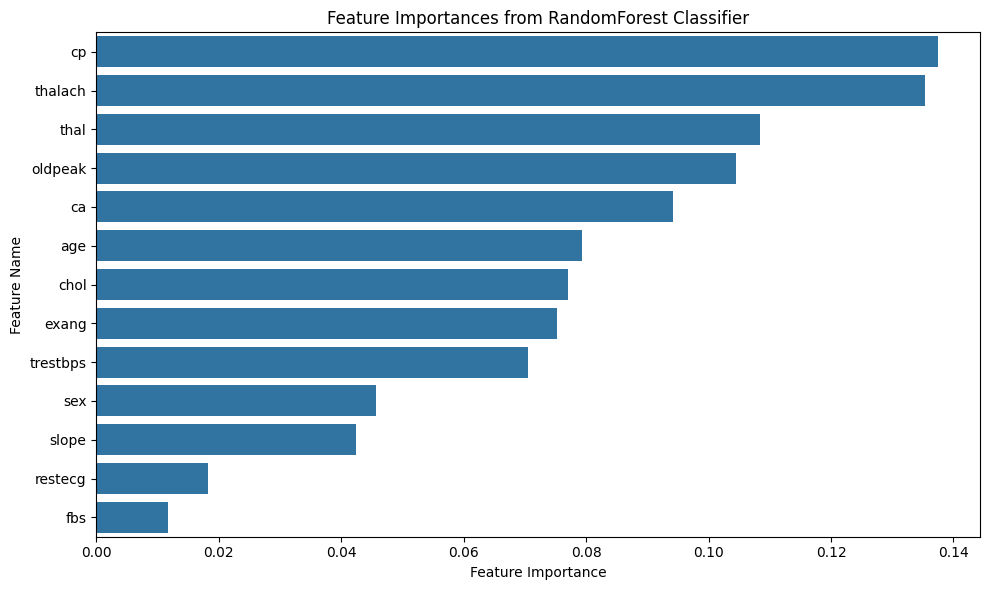

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the RandomForest model from the 'models' dictionary
# Assuming the RandomForest model in 'models' is the one you want to inspect
rf_model = models['RandomForest']

# Ensure the model has been fitted (it should have been by fit_and_score)
# If it hasn't, you would need to fit it first: rf_model.fit(X_train, y_train)

# Get the feature importances from the RandomForest model
feature_importances_rf = rf_model.feature_importances_

# Get the feature names from the training data (X_train)
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_rf_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_rf
})

# Sort features by importance in descending order
feature_importance_rf_df = feature_importance_rf_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for RandomForest Classifier:")
display(feature_importance_rf_df)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf_df)
plt.title('Feature Importances from RandomForest Classifier')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Feature Importance for Logistic Regression

For Logistic Regression, the absolute value of the coefficients can be used as an indicator of feature importance. Larger absolute coefficients mean the feature has a stronger impact on the prediction.

Feature Importances for Logistic Regression:


,Feature,Importance
1,sex,1.183356
12,thal,1.020870
2,cp,0.757103
8,exang,0.700259
11,ca,0.615008
9,oldpeak,0.561103
10,slope,0.461026
5,fbs,0.355819
6,restecg,0.353914
7,thalach,0.034407


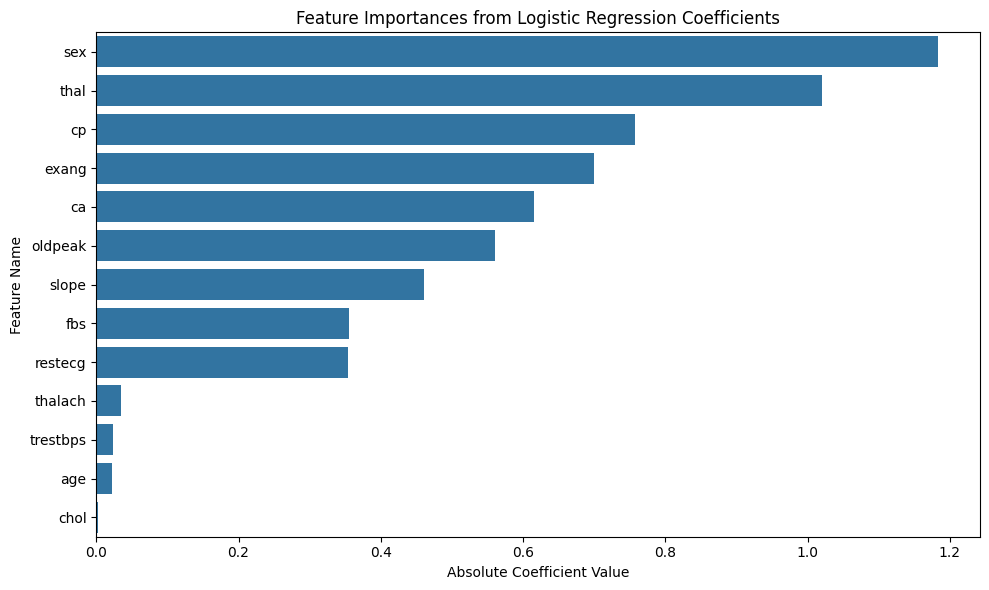

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the best estimator from GridSearchCV
best_log_reg_model = gs_log_reg.best_estimator_

# Get the coefficients (feature importances) from the logistic regression model
# We take the absolute value because the sign only indicates direction (positive/negative correlation)
feature_importances = abs(best_log_reg_model.coef_[0])

# Get the feature names from the training data (X_train)
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for Logistic Regression:")
display(feature_importance_df)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from Logistic Regression Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Removing Least Important Features for Logistic Regression

Based on the feature importance analysis, we will remove the 4 least important features: `chol`, `age`, `trestbps`, and `thalach`. Then, we will retrain and re-evaluate the Logistic Regression model.

In [ ]:
# Identify the 4 least important features from the Logistic Regression analysis
least_important_features_lr = feature_importance_df.tail(4)['Feature'].tolist()

print(f"Least important features to remove for Logistic Regression: {least_important_features_lr}")

# Create new datasets without these features
X_train_reduced_lr = X_train.drop(columns=least_important_features_lr)
X_test_reduced_lr = X_test.drop(columns=least_important_features_lr)

print(f"X_train_reduced_lr shape: {X_train_reduced_lr.shape}")
print(f"X_test_reduced_lr shape: {X_test_reduced_lr.shape}")

Least important features to remove for Logistic Regression: ['thalach', 'trestbps', 'age', 'chol']
X_train_reduced_lr shape: (242, 9)
X_test_reduced_lr shape: (61, 9)


### Retraining Logistic Regression on Reduced Features

Now, let's retrain the `GridSearchCV` for Logistic Regression using the `X_train_reduced_lr` and `X_test_reduced_lr` datasets.

In [ ]:
# Define the same hyperparameter grid for Logistic Regression
log_reg_grid_reduced = {'C': np.logspace(-4, 4, 30),
                        'solver': ['liblinear']}

# Set up GridSearchCV for Logistic Regression with the reduced feature set
gs_log_reg_reduced = GridSearchCV(LogisticRegression(max_iter=10000),
                                  param_grid=log_reg_grid_reduced,
                                  cv=5,
                                  verbose=True)

# Fit GridSearchCV to the training data with reduced features
gs_log_reg_reduced.fit(X_train_reduced_lr, y_train)

print(f"Best hyperparameters for Logistic Regression (reduced features): {gs_log_reg_reduced.best_params_}")
print(f"Best cross-validation score for Logistic Regression (reduced features): {gs_log_reg_reduced.best_score_:.4f}")

# Evaluate the best model on the test data with reduced features
log_reg_reduced_score = gs_log_reg_reduced.score(X_test_reduced_lr, y_test)
print(f"Test set score for Logistic Regression (reduced features): {log_reg_reduced_score:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters for Logistic Regression (reduced features): {'C': np.float64(9.236708571873866), 'solver': 'liblinear'}
Best cross-validation score for Logistic Regression (reduced features): 0.8514
Test set score for Logistic Regression (reduced features): 0.7705


### Comparing Results

Let's update the `model_scores` and visualize the comparison, including the new Logistic Regression model with reduced features.

,Logistic Regression,KNN,RandomForest,Logistic Regression (Reduced)
accuracy,0.770492,0.557377,0.721311,0.770492


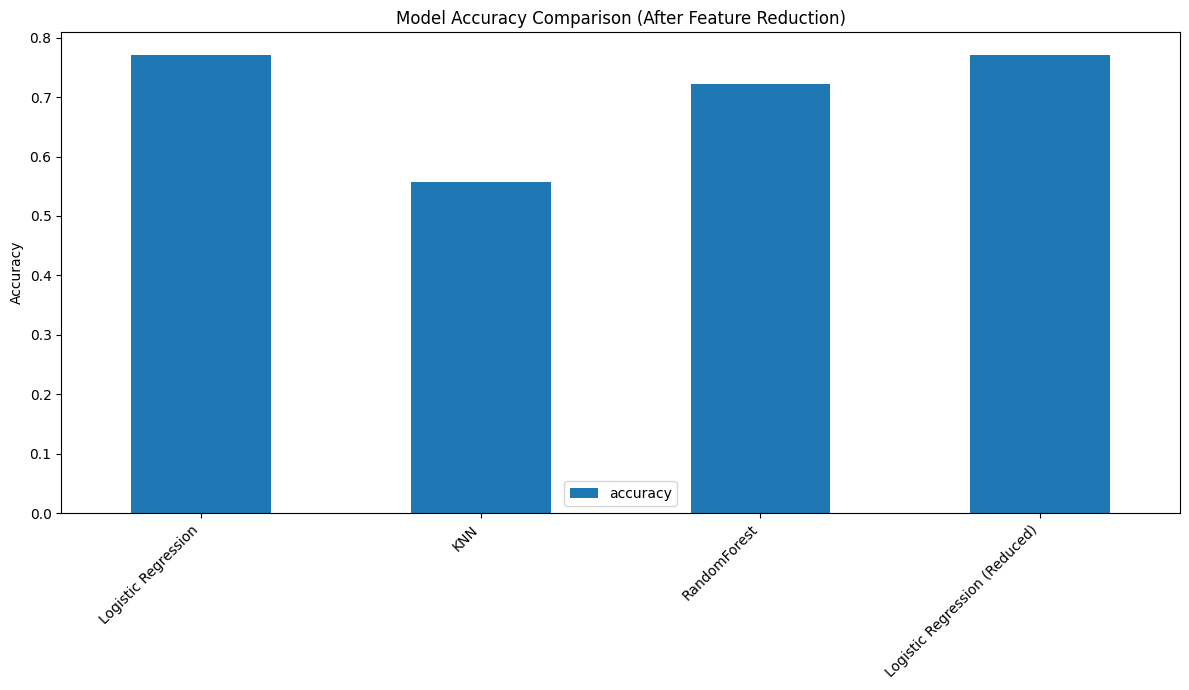

In [ ]:
# Update model_scores with the new Logistic Regression score
model_scores['Logistic Regression (Reduced)'] = log_reg_reduced_score

# Create an updated DataFrame for comparison
model_compare_final = pd.DataFrame(model_scores, index=['accuracy'])
display(model_compare_final)

# Plot the updated comparison
model_compare_final.T.plot.bar(title='Model Accuracy Comparison (After Feature Reduction)', figsize=(12, 7));
plt.ylabel('Accuracy');
plt.xticks(rotation=45, ha='right');
plt.tight_layout();
plt.show();

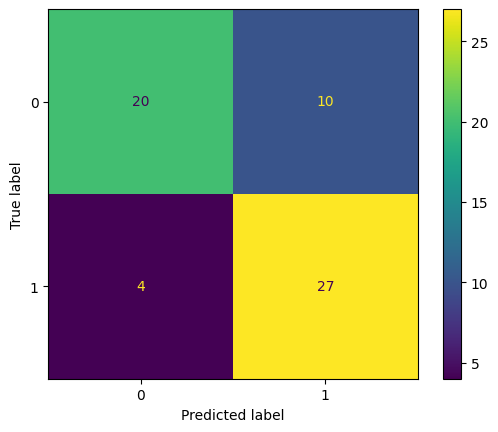

In [ ]:
# To get a confusion matrix, we need predictions and true labels
y_preds = gs_log_reg_reduced.predict(X_test_reduced_lr)

# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(gs_log_reg_reduced, X_test_reduced_lr, y_test);

### Retraining Logistic Regression on Scaled Features

Now, let's retrain the `GridSearchCV` for Logistic Regression using the `X_train_scaled` and `X_test_scaled` datasets.

In [ ]:
# Define the same hyperparameter grid for Logistic Regression
log_reg_grid_scaled = {'C': np.logspace(-4, 4, 30),
                         'solver': ['liblinear']}

# Set up GridSearchCV for Logistic Regression with the scaled feature set
gs_log_reg_scaled = GridSearchCV(LogisticRegression(max_iter=10000),
                                   param_grid=log_reg_grid_scaled,
                                   cv=5,
                                   verbose=True)

# Fit GridSearchCV to the scaled training data
gs_log_reg_scaled.fit(X_train_scaled, y_train)

print(f"Best hyperparameters for Logistic Regression (scaled features): {gs_log_reg_scaled.best_params_}")
print(f"Best cross-validation score for Logistic Regression (scaled features): {gs_log_reg_scaled.best_score_:.4f}")

# Evaluate the best model on the scaled test data
log_reg_scaled_score = gs_log_reg_scaled.score(X_test_scaled, y_test)
print(f"Test set score for Logistic Regression (scaled features): {log_reg_scaled_score:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters for Logistic Regression (scaled features): {'C': np.float64(0.05736152510448681), 'solver': 'liblinear'}
Best cross-validation score for Logistic Regression (scaled features): 0.8554
Test set score for Logistic Regression (scaled features): 0.7541


### Comparing Results After Scaling Logistic Regression

Let's update the `model_scores` and visualize the comparison, including the new Logistic Regression model with scaled features.

,Logistic Regression,KNN,RandomForest,Logistic Regression (Reduced),Logistic Regression (Scaled)
accuracy,0.770492,0.557377,0.721311,0.770492,0.754098


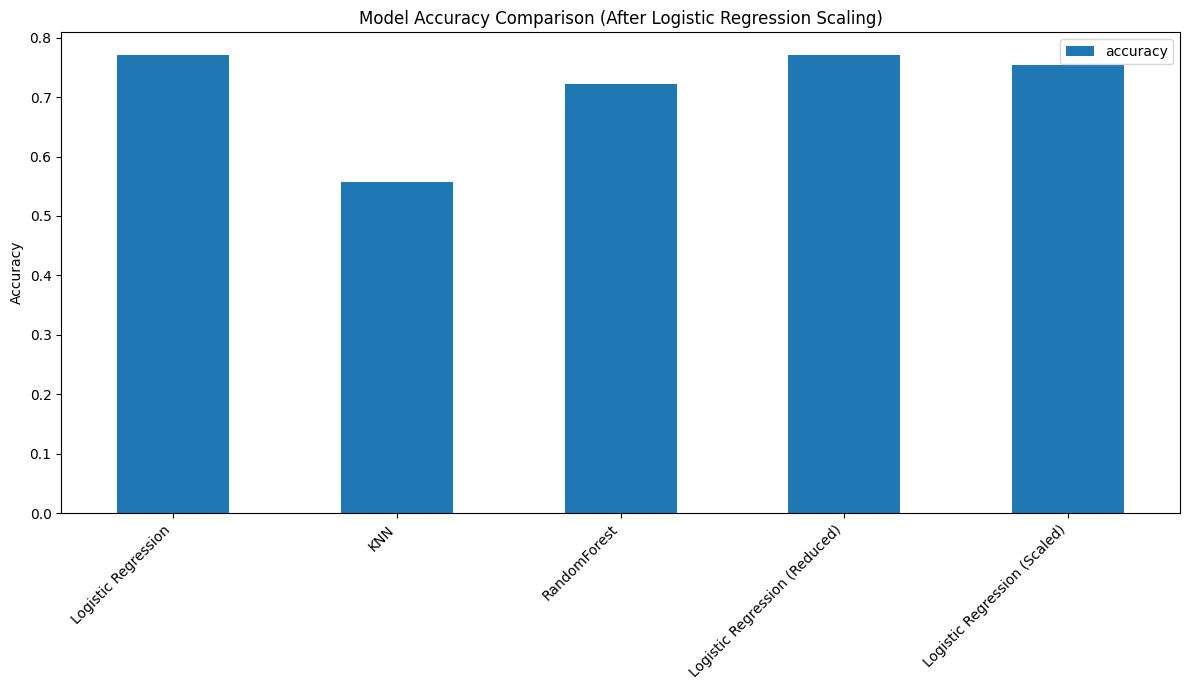

In [ ]:
# Update model_scores with the new Logistic Regression score
model_scores['Logistic Regression (Scaled)'] = log_reg_scaled_score

# Create an updated DataFrame for comparison
model_compare_final = pd.DataFrame(model_scores, index=['accuracy'])
display(model_compare_final)

# Plot the updated comparison
model_compare_final.T.plot.bar(title='Model Accuracy Comparison (After Logistic Regression Scaling)', figsize=(12, 7));
plt.ylabel('Accuracy');
plt.xticks(rotation=45, ha='right');
plt.tight_layout();
plt.show();

### Expanded Hyperparameter Tuning for Logistic Regression (Scaled Features)

We'll expand the `GridSearchCV` to include a wider range of `C` values, different `solvers`, and `penalty` types, ensuring compatibility between them. We will train on the scaled data.

### Making Predictions on New, Unseen Data

We'll create a sample of synthetic 'new data' and use our best performing model, `gs_log_reg_reduced`, to make predictions. The new data must undergo the same feature reduction steps as the training data for this model.

In [ ]:
import pandas as pd

# Create some synthetic 'new, unseen data' (example)
# It must have the same column names as the original X before reduction
new_data_raw = pd.DataFrame({
    'age': [55, 62, 48, 70],
    'sex': [1, 0, 1, 0],
    'cp': [0, 1, 2, 3],
    'trestbps': [120, 140, 130, 160],
    'chol': [230, 280, 200, 300],
    'fbs': [0, 1, 0, 0],
    'restecg': [1, 0, 1, 2],
    'thalach': [150, 120, 170, 100],
    'exang': [0, 1, 0, 1],
    'oldpeak': [1.0, 3.0, 0.5, 4.0],
    'slope': [2, 0, 1, 0],
    'ca': [0, 1, 0, 2],
    'thal': [2, 3, 2, 1]
})

display(new_data_raw)

# Identify the features that were removed from the training data for gs_log_reg_reduced
# This list comes from the 'least_important_features_lr' variable
features_to_remove = ['thalach', 'trestbps', 'age', 'chol']

# Preprocess the new data by removing the same features
new_data_reduced = new_data_raw.drop(columns=features_to_remove, errors='ignore')

print(f"New data features after reduction: {new_data_reduced.columns.tolist()}")

# Make predictions using the best performing Logistic Regression model (gs_log_reg_reduced)
new_predictions = gs_log_reg_reduced.predict(new_data_reduced)

print(f"\nPredictions for the new data: {new_predictions}")

# Optionally, get prediction probabilities
new_probabilities = gs_log_reg_reduced.predict_proba(new_data_reduced)
print(f"Prediction probabilities (class 0, class 1) for the new data:\n{new_probabilities}")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,55,1,0,120,230,0,1,150,0,1.0,2,0,2
1,62,0,1,140,280,1,0,120,1,3.0,0,1,3
2,48,1,2,130,200,0,1,170,0,0.5,1,0,2
3,70,0,3,160,300,0,2,100,1,4.0,0,2,1


New data features after reduction: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Predictions for the new data: [1 0 1 1]
Prediction probabilities (class 0, class 1) for the new data:
[[0.28970986 0.71029014]
 [0.94359032 0.05640968]
 [0.08746221 0.91253779]
 [0.41304032 0.58695968]]


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define an expanded hyperparameter grid for Logistic Regression
# We'll use a list of dictionaries to handle solver/penalty compatibility
log_reg_grid_expanded = [
    # liblinear solver supports l1 and l2 penalties
    {'C': np.logspace(-4, 4, 20),
     'solver': ['liblinear'],
     'penalty': ['l1', 'l2']},
    # lbfgs solver supports l2 penalty (and 'none', but we'll focus on regularization)
    {'C': np.logspace(-4, 4, 20),
     'solver': ['lbfgs'],
     'penalty': ['l2']},
    # saga solver supports l1, l2, and elasticnet penalties
    {'C': np.logspace(-4, 4, 20),
     'solver': ['saga'],
     'penalty': ['l1', 'l2'],
     'l1_ratio': [0.5]} # l1_ratio only for elasticnet, but good to include if saga is used with elasticnet
]

# Instantiate GridSearchCV with the expanded grid
gs_log_reg_expanded = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=log_reg_grid_expanded,
    cv=5,
    verbose=True,
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the scaled training data
gs_log_reg_expanded.fit(X_train_scaled, y_train)

print(f"Best hyperparameters for Logistic Regression (expanded grid, scaled features): {gs_log_reg_expanded.best_params_}")
print(f"Best cross-validation score for Logistic Regression (expanded grid, scaled features): {gs_log_reg_expanded.best_score_:.4f}")

# Evaluate the best model on the scaled test data
log_reg_expanded_score = gs_log_reg_expanded.score(X_test_scaled, y_test)
print(f"Test set score for Logistic Regression (expanded grid, scaled features): {log_reg_expanded_score:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best hyperparameters for Logistic Regression (expanded grid, scaled features): {'C': np.float64(0.23357214690901212), 'l1_ratio': 0.5, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation score for Logistic Regression (expanded grid, scaled features): 0.8639
Test set score for Logistic Regression (expanded grid, scaled features): 0.7213


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


### Comparing Results After Expanded Logistic Regression Tuning

Let's update the `model_scores` and visualize the comparison, including the new Logistic Regression model with the expanded tuning.

,Logistic Regression,KNN,RandomForest,Logistic Regression (Reduced),Logistic Regression (Scaled),Logistic Regression (Expanded Scaled)
accuracy,0.770492,0.557377,0.721311,0.770492,0.754098,0.721311


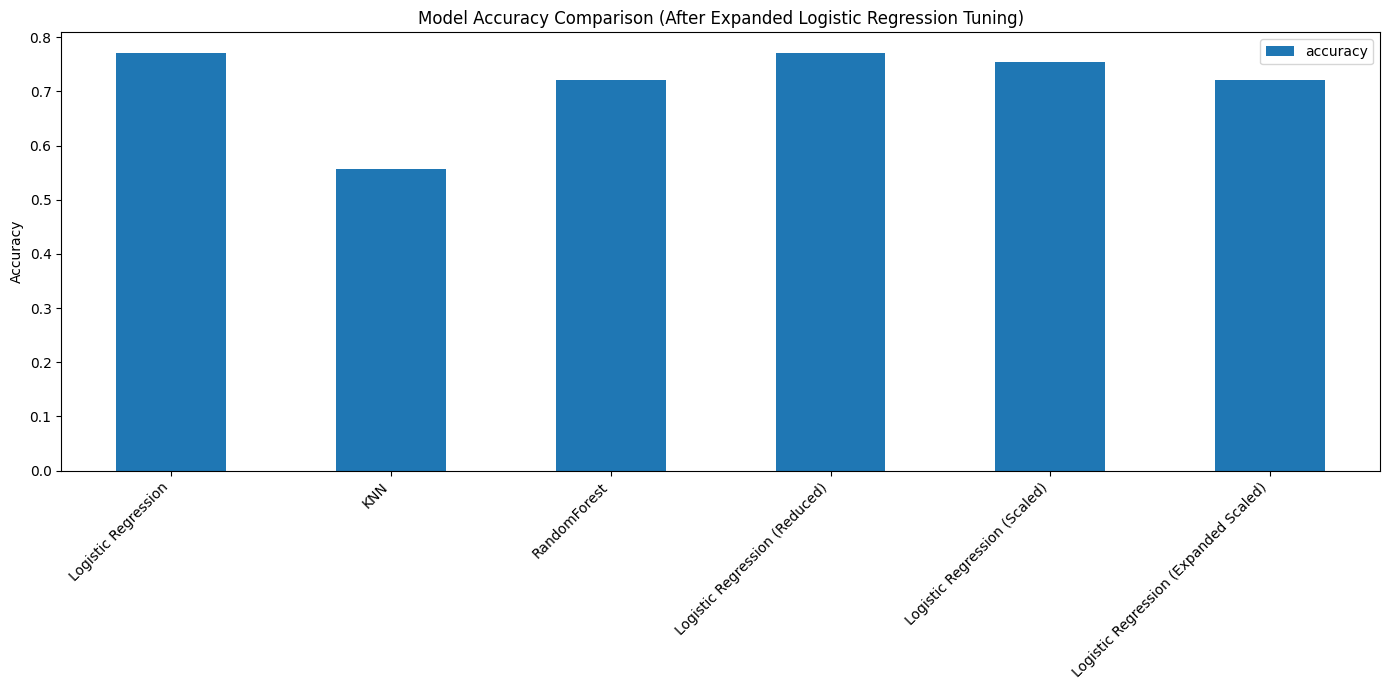

In [ ]:
# Update model_scores with the new Logistic Regression score
model_scores['Logistic Regression (Expanded Scaled)'] = log_reg_expanded_score

# Create an updated DataFrame for comparison
model_compare_final = pd.DataFrame(model_scores, index=['accuracy'])
display(model_compare_final)

# Plot the updated comparison
model_compare_final.T.plot.bar(title='Model Accuracy Comparison (After Expanded Logistic Regression Tuning)', figsize=(14, 7));
plt.ylabel('Accuracy');
plt.xticks(rotation=45, ha='right');
plt.tight_layout();
plt.show();